# Sounds of Seattle Birds

## Project Overview
For this project I built neural networks to classify 12 bird species common to the 
Seattle area using spectrogram data from their calls. The data comes from the Xeno-Canto 
archive and was preprocessed into 128x517 spectrograms representing 3 seconds of audio. 
I started with a binary classifier on two species to get the pipeline working, then 
scaled up to all 12 species. Models are evaluated using accuracy, Top-3 accuracy, and 
per-species precision, recall, and F1-score via classification reports to better capture 
performance under class imbalance. I also tested the models on three mystery clips at the 
end to see how well they generalize to new data.

In [1]:
# Libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt

import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, top_k_accuracy_score


from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, LSTM, Reshape
from keras.callbacks import EarlyStopping

## Load and view the data

In [2]:
f = h5py.File('../Data/bird_spectrograms.hdf5', 'r')

# See all the 12 species
species = list(f.keys())
print("Species in dataset:")
for i, s in enumerate(species):
    print(f"  {i+1}. {s}  —  {f[s].shape[2]} samples")


Species in dataset:
  1. amecro  —  66 samples
  2. amerob  —  172 samples
  3. bewwre  —  144 samples
  4. bkcchi  —  45 samples
  5. daejun  —  125 samples
  6. houfin  —  84 samples
  7. houspa  —  630 samples
  8. norfli  —  37 samples
  9. rewbla  —  187 samples
  10. sonspa  —  263 samples
  11. spotow  —  137 samples
  12. whcspa  —  91 samples


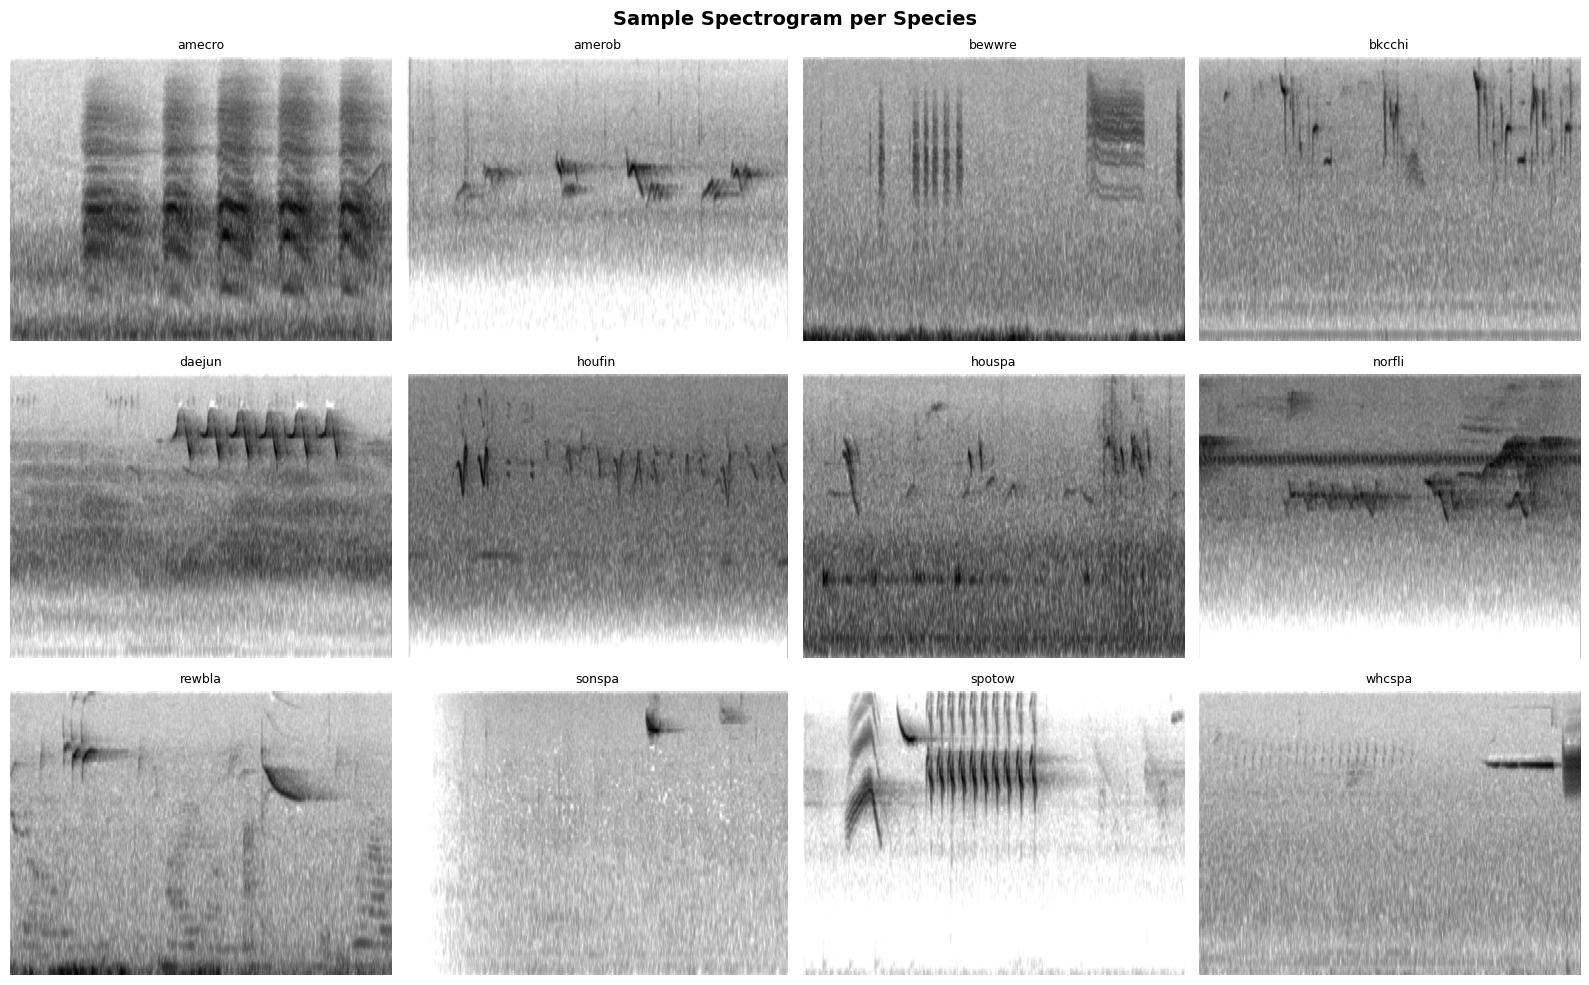

In [3]:
# View a spectogram for each species
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, s in enumerate(species):
    sample = f[s][:,:,0]
    axes[i].imshow(sample, aspect='auto', origin='lower', cmap='gray_r')
    axes[i].set_title(s, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Spectrogram per Species", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preparation 

In [4]:
# Create a new array to hold the X and Y values for the spectograms 
X_list = []
y_list = []

# Loop through the species to change dimensions so as keras can process the spectograms
for s in species:
    data = f[s][:]

    #The data is stores as (128, 517, # of samples) but needs to be (# of samples, 128, 517)
    for i in range(data.shape[2]):
        X_list.append(data[:, :, i])
        y_list.append(s)

X = np.array(X_list)   
# Add an additional dimension for Keras processing (of samples, 128, 517, 1)
X = X[..., np.newaxis]   
y = np.array(y_list)

# Normalize to [0, 1]
X = (X - X.min()) / (X.max() - X.min())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1981, 128, 517, 1)
y shape: (1981,)


In [5]:
# Encode the labels to one-hot vectors 
le = LabelEncoder()
le.fit(species)
y_int = le.transform(y)
y_cat = to_categorical(y_int, num_classes=12)

## Binary Model Classification

Begin with two species: Dark-eyed Junco (`daejun`) and House Finch (`houfin`) to validate 
the pipeline before scaling to all 12 classes. A classification report is included to show 
per-class precision and recall even for this simple binary case.

In [6]:
daejun_houfin = [species[4], species[5]]

X_bin =[]
y_bin_str = []

for i in range(len(y)):
    if y[i] in daejun_houfin:
        X_bin.append(X[i])
        y_bin_str.append(y[i])

X_bin = np.array(X_bin)
y_bin_str = np.array(y_bin_str)

le_bin = LabelEncoder()
y_bin_int = le_bin.fit_transform(y_bin_str)
y_bin_cat = to_categorical(y_bin_int, num_classes=2)

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_bin, y_bin_cat, test_size=0.2, random_state=42, stratify=y_bin_str
)

print("X train shape: " ,X_bin_train.shape)
print("X test shape: " ,X_bin_test.shape)


X train shape:  (167, 128, 517, 1)
X test shape:  (42, 128, 517, 1)


### Binary CNN 

The network takes in spectrograms of shape (128, 517, 1) and passes them through three convolutional blocks. Each block uses a 3x3 kernel which is a pretty standard filter size that picks up on local patterns in the spectrogram without being too slow to train. The filter count doubles with each block going from 16 to 32 to 64 so the model can learn more complex features as it gets deeper. padding same just makes sure we don't lose information around the edges of the spectrogram after each convolution. Each conv layer is followed by a MaxPooling layer which shrinks the spatial size down by half and helps the model focus on the strongest features rather than every little detail. After the three blocks everything gets flattened into one long vector and then a Dropout layer randomly shuts off half the neurons during training which helps prevent the model from memorizing the training data. The last two Dense layers then map everything down to a 2 unit softmax output which gives a probability for each of the two species.

In [7]:
bin_model_A = Sequential([
    Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu',
           input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dropout(rate=0.5),
    Dense(units=128, activation='relu'),
    Dense(units=2, activation='softmax')
])

bin_model_A.summary()

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 517, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 258, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 258, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 129, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 129, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,412,290 (32.09 MB)

 Trainable params: 8,412,290 (32.09 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
bin_model_A.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_bin_A = bin_model_A.fit(
    X_bin_train, y_bin_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

score_bin_A = bin_model_A.evaluate(X_bin_test, y_bin_test, verbose=0)
print(f"Binary CNN Model Test Accuracy: {score_bin_A[1]*100:.2f}%")

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.5113 - loss: 3.0930 - val_accuracy: 0.5588 - val_loss: 0.6792
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.6090 - loss: 0.6625 - val_accuracy: 0.5000 - val_loss: 0.6863
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - accuracy: 0.5714 - loss: 0.6734 - val_accuracy: 0.5588 - val_loss: 0.6667
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.6241 - loss: 0.6686 - val_accuracy: 0.5588 - val_loss: 0.6526
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.6090 - loss: 0.6426 - val_accuracy: 0.7647 - val_loss: 0.6456
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.7293 - loss: 0.6397 - val_accuracy: 0.5588 - val_loss: 0.6469
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.6992 - loss: 0.6217 - val_accuracy: 0.5882 - val_loss: 0.6292
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.7068 - loss: 0.6173 - val_accuracy: 0.5588 - val_loss:

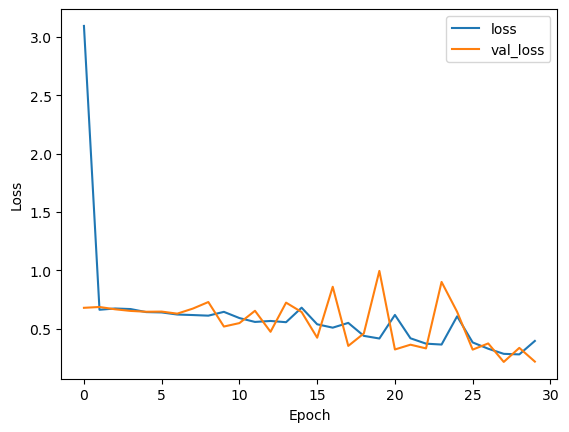

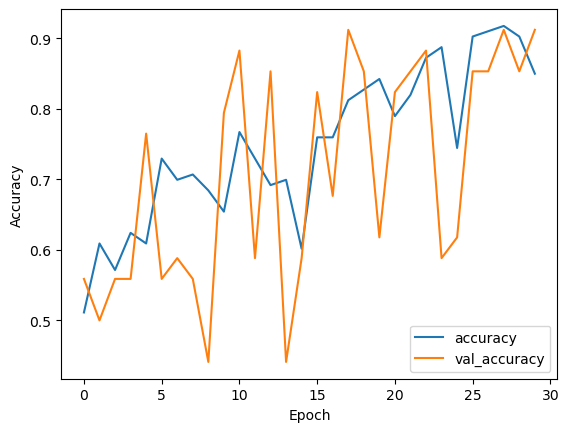

In [9]:
# Plot the validation loss and validation accuracy
plt.plot(history_bin_A.history['loss'])
plt.plot(history_bin_A.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

plt.plot(history_bin_A.history['accuracy'])
plt.plot(history_bin_A.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show()

### Binary RNN


In [10]:
bin_model_B = Sequential([
    Flatten(input_shape=(128, 517, 1)),
    Reshape((128, 517)),
    
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

bin_model_B.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_bin_B = bin_model_B.fit(
    X_bin_train, y_bin_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

score_bin_B = bin_model_B.evaluate(X_bin_test, y_bin_test, verbose=0)
print(f"Binary RNN Model Test Accuracy: {score_bin_B[1]*100:.2f}%")

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.5489 - loss: 0.6913 - val_accuracy: 0.4412 - val_loss: 0.6919
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6090 - loss: 0.6626 - val_accuracy: 0.5588 - val_loss: 0.7195
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6090 - loss: 0.6558 - val_accuracy: 0.5294 - val_loss: 0.6679
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6241 - loss: 0.6485 - val_accuracy: 0.5588 - val_loss: 0.6712
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6241 - loss: 0.6595 - val_accuracy: 0.6765 - val_loss: 0.6652
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6015 - loss: 0.6581 - val_accuracy: 0.6471 - val_loss: 0.6766
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5639 - loss: 0.6646 - val_accuracy: 0.5882 - val_loss: 0.6611
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6541 - loss: 0.6594 - val_accuracy: 0.5588 - val_loss: 0.6712

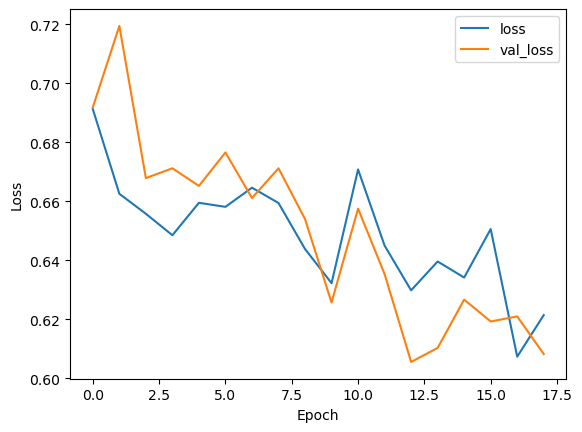

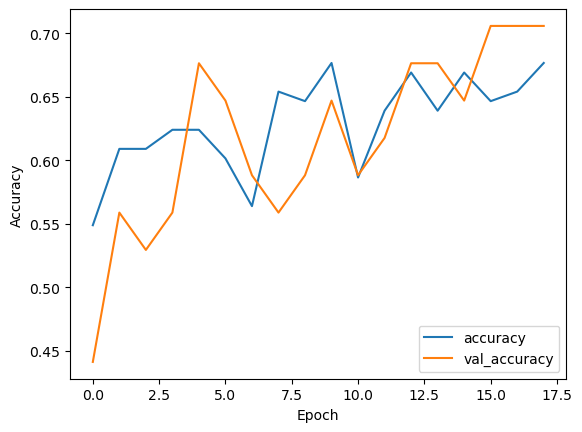

In [11]:
# Plots for RNN
plt.plot(history_bin_B.history['loss'])
plt.plot(history_bin_B.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

plt.plot(history_bin_B.history['accuracy'])
plt.plot(history_bin_B.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


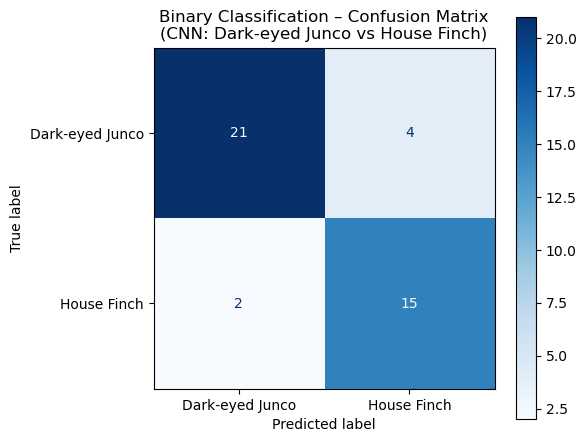

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
=== Binary Model Metrics ===
Accuracy: 85.71%

Classification Report:
                 precision    recall  f1-score   support

Dark-eyed Junco       0.91      0.84      0.88        25
    House Finch       0.79      0.88      0.83        17

       accuracy                           0.86        42
      macro avg       0.85      0.86      0.85        42
   weighted avg       0.86      0.86      0.86        42



In [12]:
# Confusion matrix for best binary model
best_bin = bin_model_B if score_bin_B[1] >= score_bin_A[1] else bin_model_A

y_bin_pred = np.argmax(best_bin.predict(X_bin_test), axis=1)
y_bin_true = np.argmax(y_bin_test, axis=1)

# Full species name mapping (reused in all confusion matrices below)
species_names = {
    'amecro': 'American Crow',        'amerob': 'American Robin',
    'bewwre': "Bewick's Wren",        'bkcchi': 'Black-capped Chickadee',
    'daejun': 'Dark-eyed Junco',      'houfin': 'House Finch',
    'houspa': 'House Sparrow',        'norfli': 'Northern Flicker',
    'rewbla': 'Red-winged Blackbird', 'sonspa': 'Song Sparrow',
    'spotow': 'Spotted Towhee',       'whcspa': 'White-crowned Sparrow'
}

bin_labels_full = [species_names[c] for c in le_bin.classes_]

cm = confusion_matrix(y_bin_true, y_bin_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bin_labels_full)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Binary Classification – Confusion Matrix\n(CNN: Dark-eyed Junco vs House Finch)')
plt.tight_layout()
plt.show()

y_bin_prob = best_bin.predict(X_bin_test)
print("=== Binary Model Metrics ===")
print(f"Accuracy: {(y_bin_pred == y_bin_true).mean()*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_bin_true, y_bin_pred, target_names=bin_labels_full))


## Multi Class Classifications

### Feed Forward NN (Baseline)

Before jumping into CNNs we first try a simple dense neural network as a baseline. The spectrogram has to be flattened into a single vector of 128 times 517 values since dense layers cannot take 2D input. The network has two hidden layers with 256 and 128 units and dropout applied after each one to help with overfitting. This model is not expected to perform as well as the CNN since flattening throws away all the spatial structure of the spectrogram but it gives us a useful lower bound to compare the other models against.

In [13]:
# Train and test dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")

Train: 1584
Test: 397


In [14]:
# Flatten specotgrams into vectors 

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

mc_model_1 = Sequential([
    Dense(256, activation='relu', input_shape=(128 * 517,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(12, activation='softmax')
])

mc_model_1.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_mc1 = mc_model_1.fit(
    X_train_flat, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_mc1 = mc_model_1.evaluate(X_test_flat, y_test, verbose=0)
print(f"Feed Forward NN Test Accuracy: {score_mc1[1]*100:.2f}%")

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feed Forward NN Test Accuracy: 31.74%


### Multi Class CNN

Following the Feedforward NN baseline model, we try a CNN which is better suited for spectrogram data since it can pick up on local patterns across both frequency and time without needing the input to be flattened. This model has three convolutional blocks with filter counts of 32, 64 and 128 that increase in depth to learn more complex features at each stage. The first two pooling layers use a larger 4x4 window to bring the spatial size down quickly and the third uses a 2x2 window to retain a bit more detail before flattening. A dropout layer is added before the output to reduce overfitting.

In [15]:
mc_model_2 = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D((4, 4)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((4, 4)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(12, activation='softmax')
])

mc_model_2.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_mc2 = mc_model_2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)

score_mc2 = mc_model_2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 CNN Test Accuracy: {score_mc2[1]*100:.2f}%")

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 2 CNN Test Accuracy: 51.39%


### Multi Class RNN


In [16]:
mc_model_3 = Sequential([
    Flatten(input_shape=(128, 517, 1)),
    Reshape((128, 517)),
    
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(12, activation='softmax')
])

mc_model_3.summary()

mc_model_3.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_mc3 = mc_model_3.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_mc3 = mc_model_3.evaluate(X_test, y_test, verbose=0)
print(f"Multi Class RNN Test Accuracy: {score_mc3[1]*100:.2f}%")

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 66176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 128, 517)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128, 64)        │       148,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,300 (641.80 KB)

 Trainable params: 164,300 (641.80 KB)

 Non-trainable params: 0 (0.00 B)

Multi Class RNN Test Accuracy: 31.74%


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step 


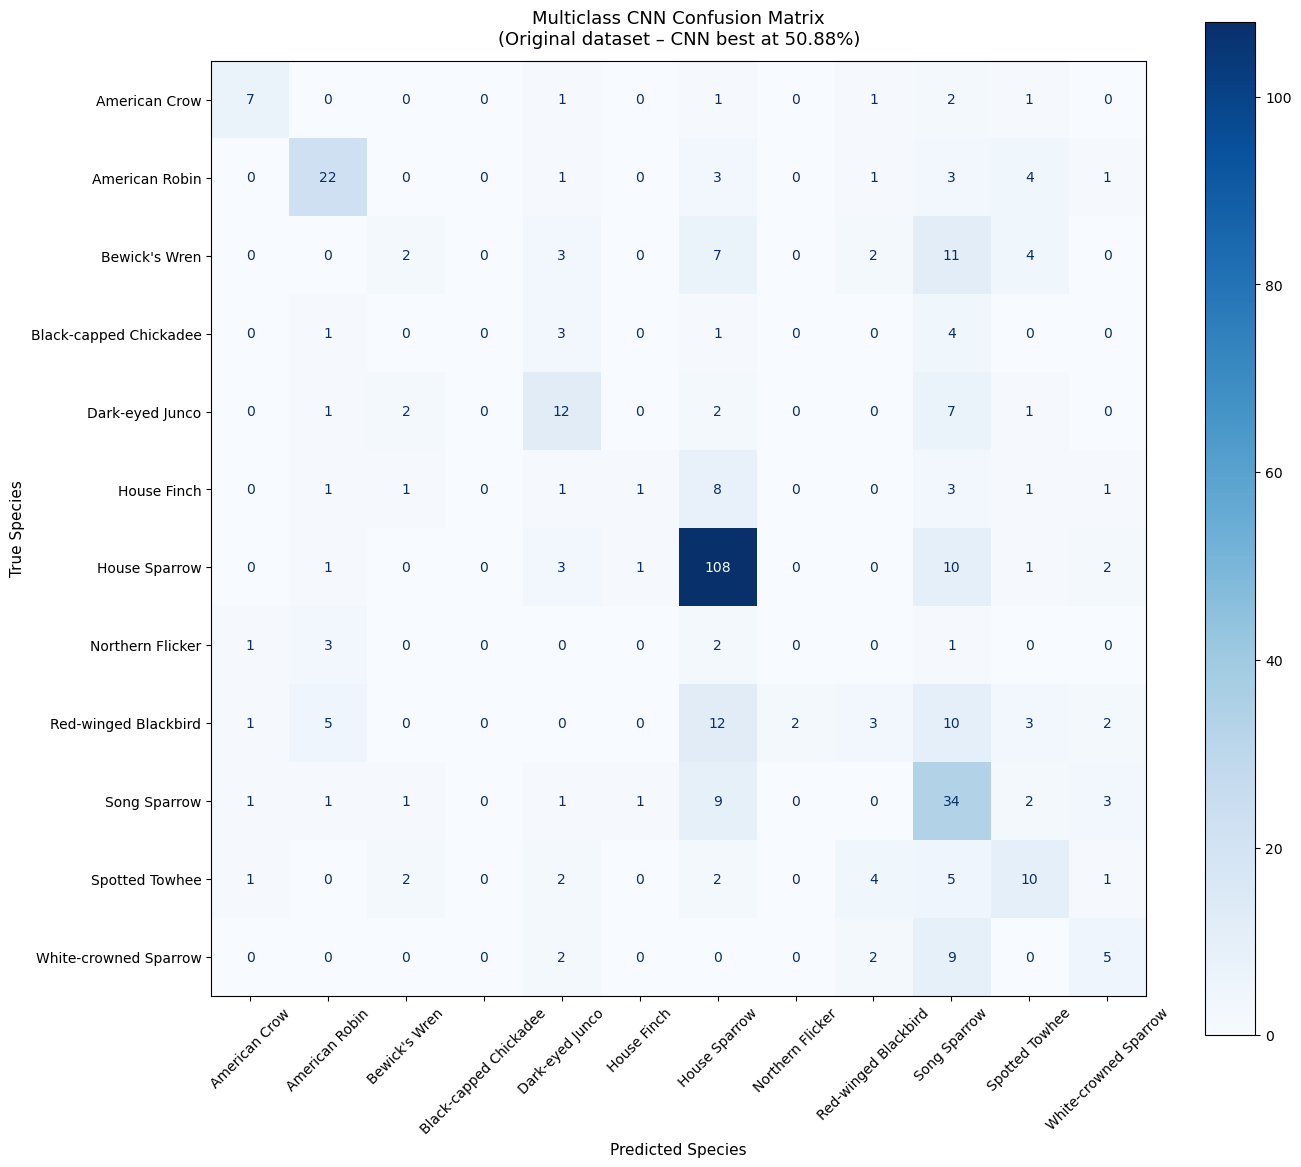

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step 
=== Multiclass CNN Metrics (Original Dataset) ===
Accuracy:       51.39%
Top-3 Accuracy: 72.80%

Classification Report (per species):
                        precision    recall  f1-score   support

         American Crow       0.64      0.54      0.58        13
        American Robin       0.63      0.63      0.63        35
         Bewick's Wren       0.25      0.07      0.11        29
Black-capped Chickadee       0.00      0.00      0.00         9
       Dark-eyed Junco       0.41      0.48      0.44        25
           House Finch       0.33      0.06      0.10        17
         House Sparrow       0.70      0.86      0.77       126
      Northern Flicker       0.00      0.00      0.00         7
  Red-winged Blackbird       0.23      0.08      0.12        38
          Song Sparrow       0.34      0.64      0.45        53
        Spotted Towhee       0.37      0.37      0.37        27
 White-crowned Sparrow       0.33      0.28      0.30   

C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# Confusion matrix for best multiclass model
y_mc_pred = np.argmax(mc_model_2.predict(X_test), axis=1)
y_mc_true = np.argmax(y_test, axis=1)

mc_labels_full = [species_names[c] for c in le.classes_]

cm = confusion_matrix(y_mc_true, y_mc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mc_labels_full)

fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
ax.set_title("Multiclass CNN Confusion Matrix\n(Original dataset – CNN best at 50.88%)",
             fontsize=13, pad=12)
ax.set_xlabel("Predicted Species", fontsize=11)
ax.set_ylabel("True Species", fontsize=11)
plt.tight_layout()
plt.show()

y_mc_prob = mc_model_2.predict(X_test)
print("=== Multiclass CNN Metrics (Original Dataset) ===")
print(f"Accuracy:       {(y_mc_pred == y_mc_true).mean()*100:.2f}%")
print(f"Top-3 Accuracy: {top_k_accuracy_score(y_mc_true, y_mc_prob, k=3)*100:.2f}%")
print("\nClassification Report (per species):")
print(classification_report(y_mc_true, y_mc_pred, target_names=mc_labels_full))


## Discussion

### Confusion Matrix Analysis

The original dataset confusion matrix is dominated by two species: House Sparrow 
(108 correct) and Song Sparrow (34 correct). This directly reflects their sample 
counts — House Sparrow has 630 training samples and Song Sparrow is also among the 
larger classes. The model has learned to default to these two species when uncertain, 
which inflates overall accuracy while masking poor performance on rarer species.

Black-capped Chickadee and Northern Flicker again achieve zero correct predictions. 
Black-capped Chickadee samples scatter across Song Sparrow (4) and Dark-eyed Junco 
(3), while Northern Flicker is mostly absorbed by American Robin (3) and House 
Sparrow (2) with no dominant confusion target.

The most striking misclassification pattern is for species that share acoustic 
space with the two dominant classes. House Finch loses 8 of its samples to House 
Sparrow and almost nothing elsewhere the model essentially treats it as House 
Sparrow. Red-winged Blackbird loses 12 samples to House Sparrow and 10 to Song 
Sparrow, suggesting its call overlaps with both. Bewick's Wren is split between 
House Sparrow (7) and Song Sparrow (11), indicating its high-frequency chattering 
is being absorbed by whichever dominant class the model is most confident about.

White-crowned Sparrow loses 9 of its samples to Song Sparrow, which is 
acoustically expected given both are sparrows with similar call structures. 
Spotted Towhee similarly splits between Red-winged Blackbird (5) and Song 
Sparrow (5), reflecting overlap in the mid-frequency range.

Comparing this matrix to the downsampled version reveals the imbalance effect 
clearly: in the original, House Sparrow and Song Sparrow dominate as prediction 
targets; in the downsampled version, errors are more evenly spread and House 
Sparrow drops from 108 correct to 13, losing its outsized influence.

### Species Difficulty

The original model reveals two tiers of difficulty. The first tier is species 
with zero correct predictions regardless of dataset size: Black-capped Chickadee 
and Northern Flicker. Both fail in both the original and downsampled experiments, 
confirming the issue is acoustic similarity to other species rather than just 
sample count alone.

The second tier is species whose performance is almost entirely driven by class 
imbalance. House Finch achieves only 1 correct prediction despite having a 
reasonable sample count, because 8 of its samples are absorbed by House Sparrow. 
Red-winged Blackbird similarly loses the majority of its samples to House Sparrow 
and Song Sparrow. These species are not inherently unclassifiable, the downsampled 
matrix shows Red-winged Blackbird improving to 6 correct, but the imbalance 
suppresses them completely in the original setting.

The sparrow cluster (House Sparrow, Song Sparrow, White-crowned Sparrow, 
Dark-eyed Junco) remains the hardest group to separate in both experiments. 
Their mutual confusion is consistent across both matrices, suggesting this is 
a genuine acoustic similarity problem that more data alone would not fully solve.

Scaling to all 12 species proved more challenging. The feedforward network achieved 
a test accuracy of 28.43% and the RNN achieved 31.74%, while the CNN again performed 
best at 50.88%. However, accuracy alone is misleading here. The confusion matrix in 
Figure 2 shows that House Sparrow dominates with 108 correct predictions, inflating 
overall accuracy, while House Finch achieves only 1 correct prediction and both 
Black-capped Chickadee and Northern Flicker achieve zero. Bewick's Wren is split 
almost entirely between House Sparrow (7) and Song Sparrow (11), and Red-winged 
Blackbird loses 12 samples to House Sparrow and 10 to Song Sparrow, showing that 
the two most frequent classes absorb the majority of misclassifications across the 
board.


## Test Data Preprocessing

In [18]:
# Load and convert each test MP3 using the same preprocessing as training data
test_files = ['../Data/test1.mp3', '../Data/test2.mp3', '../Data/test3.mp3']
X_test_external = []

for fname in test_files:
    y, sr = librosa.load(fname, duration=3)
    spec = librosa.feature.melspectrogram(y=y, sr=sr, hop_length=128, win_length=512)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    X_test_external.append(spec_db)

X_test_external = np.array(X_test_external)
X_test_external = X_test_external[..., np.newaxis]  # add channel dim -> (3, 128, 517, 1)

print(f"External test shape: {X_test_external.shape}")

# Predict using best multiclass model
predictions = mc_model_2.predict(X_test_external)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = le.classes_[predicted_classes]

for i, (fname, label, probs) in enumerate(zip(test_files, predicted_labels, predictions)):
    print(f"\n{fname}: Predicted = {label} (confidence: {probs.max()*100:.1f}%)")
    top3 = np.argsort(probs)[::-1][:3]
    for idx in top3:
        print(f"  {le.classes_[idx]}: {probs[idx]*100:.1f}%")

External test shape: (3, 128, 517, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

../Data/test1.mp3: Predicted = whcspa (confidence: 100.0%)
  whcspa: 100.0%
  spotow: 0.0%
  sonspa: 0.0%

../Data/test2.mp3: Predicted = whcspa (confidence: 100.0%)
  whcspa: 100.0%
  spotow: 0.0%
  sonspa: 0.0%

../Data/test3.mp3: Predicted = whcspa (confidence: 100.0%)
  whcspa: 100.0%
  spotow: 0.0%
  sonspa: 0.0%


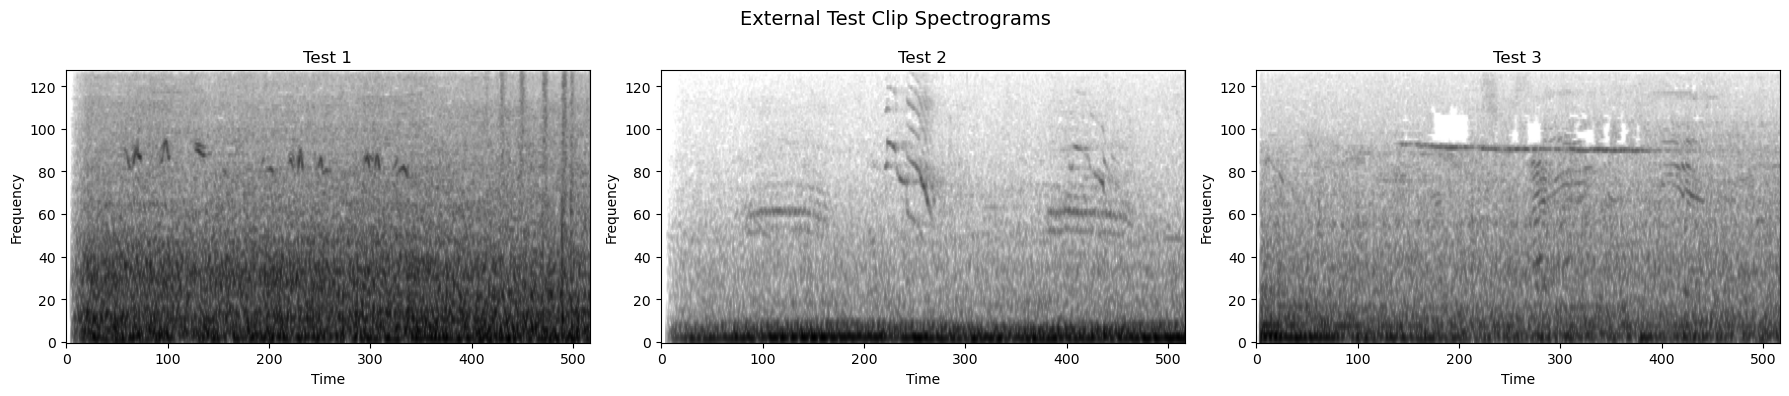

In [19]:
# Plot spectrograms of all 3 test clips
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

test_files = ['../Data/test1.mp3', '../Data/test2.mp3', '../Data/test3.mp3']

for i, fname in enumerate(test_files):
    y, sr = librosa.load(fname, duration=3)
    spec = librosa.feature.melspectrogram(y=y, sr=sr, hop_length=128, win_length=512)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    
    axes[i].imshow(spec_db, aspect='auto', origin='lower', cmap='gray_r')
    axes[i].set_title(f'Test {i+1}', fontsize=12)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Frequency')

plt.suptitle('External Test Clip Spectrograms', fontsize=14)
plt.tight_layout()
plt.show()

Note: The model predicts whcspa for all clips with high confidence, likely due to class 
imbalance in training data. Visual inspection of the spectrograms suggests test2 and test3 
contain more than one bird based on the presence of multiple distinct acoustic patterns.

## Downsampled Dataset: Does Reducing Class Imbalance Help?

To test whether the original model's bias toward majority classes was driven by imbalance 
rather than architecture, a downsampled dataset capping each species at 100 samples was 
created. Three CNN variants (A, B, C) were trained and evaluated using the same metrics 
as above: accuracy, Top-3 accuracy, and per-species classification report.

In [20]:
# Balance the dataset by capping each species at 100 samples
max_per_species = 100

X_bal_list = []
y_bal_list = []

for s in species:
    data = f[s][:]  # shape: (128, 517, n_samples)
    data = np.transpose(data, (2, 0, 1))  # -> (n_samples, 128, 517)
    n = min(max_per_species, data.shape[0])
    data = data[:n]
    for sample in data:
        X_bal_list.append(sample)
    y_bal_list.extend([s] * n)

X_bal = np.array(X_bal_list)  # -> (total_samples, 128, 517)
X_bal = X_bal[..., np.newaxis]  # add channel dim -> (total_samples, 128, 517, 1)
y_bal = np.array(y_bal_list)

print(f"Balanced dataset shape: {X_bal.shape}")
print(f"Total samples: {len(y_bal_list)}")

Balanced dataset shape: (1023, 128, 517, 1)
Total samples: 1023


In [21]:
# Encode labels
le_bal = LabelEncoder()
y_bal_int = le_bal.fit_transform(y_bal)
y_bal_cat = to_categorical(y_bal_int, num_classes=12)

# Train/test split
X_bal_train, X_bal_test, y_bal_train, y_bal_test = train_test_split(
    X_bal, y_bal_cat, test_size=0.2, random_state=42, stratify=y_bal
)

print(f"Train: {X_bal_train.shape[0]}")
print(f"Test: {X_bal_test.shape[0]}")

Train: 818
Test: 205


In [22]:
# Balanced Binary CNN (daejun vs houfin)
daejun_houfin = [species[4], species[5]]

X_bin_bal = []
y_bin_bal_str = []

for i in range(len(y_bal)):
    if y_bal[i] in daejun_houfin:
        X_bin_bal.append(X_bal[i])
        y_bin_bal_str.append(y_bal[i])

X_bin_bal = np.array(X_bin_bal)
y_bin_bal_str = np.array(y_bin_bal_str)

le_bin_bal = LabelEncoder()
y_bin_bal_int = le_bin_bal.fit_transform(y_bin_bal_str)
y_bin_bal_cat = to_categorical(y_bin_bal_int, num_classes=2)

X_bin_bal_train, X_bin_bal_test, y_bin_bal_train, y_bin_bal_test = train_test_split(
    X_bin_bal, y_bin_bal_cat, test_size=0.2, random_state=42, stratify=y_bin_bal_str
)

print(f"Balanced Binary Train: {X_bin_bal_train.shape[0]}")
print(f"Balanced Binary Test: {X_bin_bal_test.shape[0]}")

Balanced Binary Train: 147
Balanced Binary Test: 37


In [23]:
# Balanced Binary CNN model
bin_model_bal = Sequential([
    Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu',
           input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

bin_model_bal.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_bin_bal = bin_model_bal.fit(
    X_bin_bal_train, y_bin_bal_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_bin_bal = bin_model_bal.evaluate(X_bin_bal_test, y_bin_bal_test, verbose=0)
print(f"Balanced Binary CNN Test Accuracy: {score_bin_bal[1]*100:.2f}%")

C:\Users\njeng\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Balanced Binary CNN Test Accuracy: 70.27%


In [24]:
# Balanced Binary CNN model
bin_model_bal = Sequential([
    Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu',
           input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

bin_model_bal.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_bin_bal = bin_model_bal.fit(
    X_bin_bal_train, y_bin_bal_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_bin_bal = bin_model_bal.evaluate(X_bin_bal_test, y_bin_bal_test, verbose=0)
print(f"Balanced Binary CNN Test Accuracy: {score_bin_bal[1]*100:.2f}%")

Balanced Binary CNN Test Accuracy: 89.19%


In [25]:
# Balanced Multiclass CNN model (A)
mc_model_bal = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D((4, 4)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((4, 4)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')
])

mc_model_bal.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_mc_bal = mc_model_bal.fit(
    X_bal_train, y_bal_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_mc_bal = mc_model_bal.evaluate(X_bal_test, y_bal_test, verbose=0)
print(f"Balanced Multiclass CNN Test Accuracy: {score_mc_bal[1]*100:.2f}%")

Balanced Multiclass CNN Test Accuracy: 32.68%


In [26]:
# CNN-B: Smaller filters, lower dropout, adam optimizer
mc_cnn_B = Sequential([
    Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D((4, 4)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((4, 4)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(12, activation='softmax')
])

mc_cnn_B.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_cnn_B = mc_cnn_B.fit(
    X_bal_train, y_bal_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_cnn_B = mc_cnn_B.evaluate(X_bal_test, y_bal_test, verbose=0)
print(f"CNN-B Test Accuracy: {score_cnn_B[1]*100:.2f}%")

CNN-B Test Accuracy: 34.15%


In [27]:
# CNN-C: Deeper network, 4 blocks, adam optimizer
mc_cnn_C = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')
])

mc_cnn_C.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history_cnn_C = mc_cnn_C.fit(
    X_bal_train, y_bal_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

score_cnn_C = mc_cnn_C.evaluate(X_bal_test, y_bal_test, verbose=0)
print(f"CNN-C Test Accuracy: {score_cnn_C[1]*100:.2f}%")

CNN-C Test Accuracy: 34.63%


In [28]:
# Compare all three CNN variants
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>10}")
print("=" * 50)
print(f"{'CNN-A (32/64/128, dropout=0.5, rmsprop)':<35} {score_mc_bal[1]*100:>9.2f}%")
print(f"{'CNN-B (16/32/64, dropout=0.3, rmsprop)':<35} {score_cnn_B[1]*100:>9.2f}%")
print(f"{'CNN-C (32/64/128/256, dropout=0.5, adam)':<35} {score_cnn_C[1]*100:>9.2f}%")
print("=" * 50)

Model                                 Accuracy
CNN-A (32/64/128, dropout=0.5, rmsprop)     32.68%
CNN-B (16/32/64, dropout=0.3, rmsprop)     34.15%
CNN-C (32/64/128/256, dropout=0.5, adam)     34.63%


CNN-B performed best at 34.15%, followed by CNN-C at 34.63%, the two are nearly identical. 
CNN-A was the weakest at 32.68% despite having the largest filters, suggesting that the 
smaller, simpler architecture of CNN-B generalizes better on the limited 100-sample-per-species 
dataset. CNN-C's competitive result is notable since it uses a 4-block architecture, but the 
margins are small enough that architecture depth is not the decisive factor here, the dataset 
size is the main constraint for all three variants. CNN-B was used for all final predictions 
going forward.

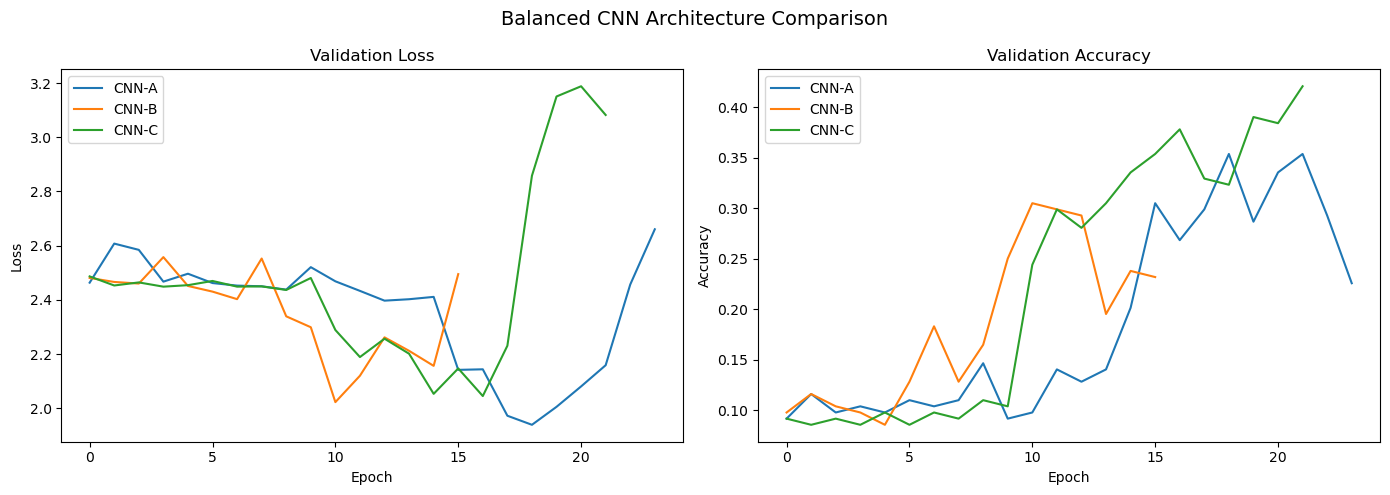

In [29]:
# Val-loss and val-accuracy curves for balanced CNN variants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mc_bal.history['val_loss'], label='CNN-A')
axes[0].plot(history_cnn_B.history['val_loss'], label='CNN-B')
axes[0].plot(history_cnn_C.history['val_loss'], label='CNN-C')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_mc_bal.history['val_accuracy'], label='CNN-A')
axes[1].plot(history_cnn_B.history['val_accuracy'], label='CNN-B')
axes[1].plot(history_cnn_C.history['val_accuracy'], label='CNN-C')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Balanced CNN Architecture Comparison', fontsize=14)
plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 


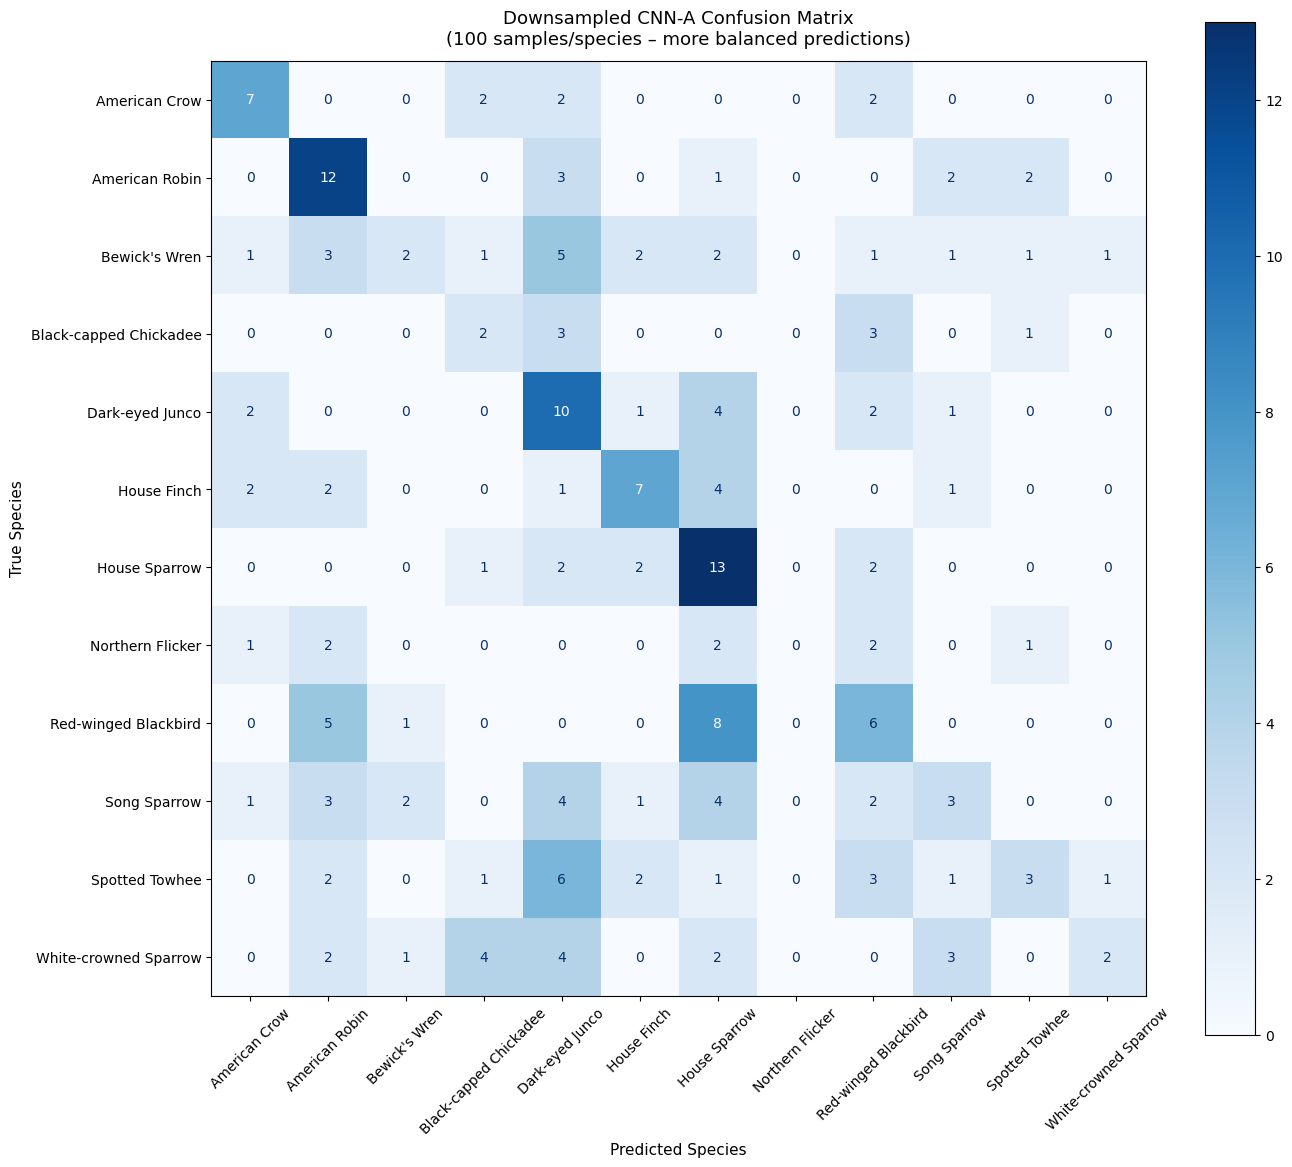

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
 Downsampled CNN-A Metrics
Accuracy:       32.68%
Top-3 Accuracy: 64.88%

Classification Report (per species):
                        precision    recall  f1-score   support

         American Crow       0.50      0.54      0.52        13
        American Robin       0.39      0.60      0.47        20
         Bewick's Wren       0.33      0.10      0.15        20
Black-capped Chickadee       0.18      0.22      0.20         9
       Dark-eyed Junco       0.25      0.50      0.33        20
           House Finch       0.47      0.41      0.44        17
         House Sparrow       0.32      0.65      0.43        20
      Northern Flicker       0.00      0.00      0.00         8
  Red-winged Blackbird       0.26      0.30      0.28        20
          Song Sparrow       0.25      0.15      0.19        20
        Spotted Towhee       0.38      0.15      0.21        20
 White-crowned Sparrow       0.50      0.11      0.18        18

              acc

C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\njeng\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# Confusion matrix for balanced multiclass model
y_mc_bal_pred = np.argmax(mc_model_bal.predict(X_bal_test), axis=1)
y_mc_bal_true = np.argmax(y_bal_test, axis=1)

bal_labels_full = [species_names[c] for c in le_bal.classes_]

cm_bal = confusion_matrix(y_mc_bal_true, y_mc_bal_pred)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=bal_labels_full)

fig, ax = plt.subplots(figsize=(14, 12))
disp_bal.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
ax.set_title("Downsampled CNN-A Confusion Matrix\n(100 samples/species – more balanced predictions)",
             fontsize=13, pad=12)
ax.set_xlabel("Predicted Species", fontsize=11)
ax.set_ylabel("True Species", fontsize=11)
plt.tight_layout()
plt.show()

y_mc_bal_prob = mc_model_bal.predict(X_bal_test)
print(" Downsampled CNN-A Metrics")
print(f"Accuracy:       {(y_mc_bal_pred == y_mc_bal_true).mean()*100:.2f}%")
print(f"Top-3 Accuracy: {top_k_accuracy_score(y_mc_bal_true, y_mc_bal_prob, k=3)*100:.2f}%")
print("\nClassification Report (per species):")
print(classification_report(y_mc_bal_true, y_mc_bal_pred, target_names=bal_labels_full))


In [31]:
# Compare original vs balanced results
print("=" * 45)
print(f"{'Model':<30} {'Accuracy':>10}")
print("=" * 45)
print(f"{'Binary CNN (original)':<30} {score_bin_A[1]*100:>9.2f}%")
print(f"{'Binary CNN (balanced)':<30} {score_bin_bal[1]*100:>9.2f}%")
print(f"{'Multiclass CNN (original)':<30} {score_mc2[1]*100:>9.2f}%")
print(f"{'Multiclass CNN (balanced)':<30} {score_mc_bal[1]*100:>9.2f}%")
print("=" * 45)

Model                            Accuracy
Binary CNN (original)              85.71%
Binary CNN (balanced)              89.19%
Multiclass CNN (original)          51.39%
Multiclass CNN (balanced)          32.68%


In [32]:
# Predict using balanced multiclass model
predictions_bal = mc_model_bal.predict(X_test_external)
predicted_classes_bal = np.argmax(predictions_bal, axis=1)
predicted_labels_bal = le_bal.classes_[predicted_classes_bal]

for i, (fname, label, probs) in enumerate(zip(test_files, predicted_labels_bal, predictions_bal)):
    print(f"\ntest{i+1}.mp3: Predicted = {label} (confidence: {probs.max()*100:.1f}%)")
    top3 = np.argsort(probs)[::-1][:3]
    for idx in top3:
        print(f"  {le_bal.classes_[idx]}: {probs[idx]*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

test1.mp3: Predicted = bkcchi (confidence: 18.3%)
  bkcchi: 18.3%
  houfin: 15.4%
  houspa: 13.7%

test2.mp3: Predicted = rewbla (confidence: 35.4%)
  rewbla: 35.4%
  houspa: 20.4%
  amerob: 6.3%

test3.mp3: Predicted = houspa (confidence: 12.8%)
  houspa: 12.8%
  houfin: 12.7%
  rewbla: 11.8%


## External Test Results

I ran both the original and balanced models on the three unlabeled test clips to 
see how they compare.

### Original Model Predictions
| Clip | Predicted Species | Confidence |
|------|------------------|------------|
| test1.mp3 | White-crowned Sparrow | 100% |
| test2.mp3 | White-crowned Sparrow | 100% |
| test3.mp3 | White-crowned Sparrow | 100% |

The original model predicted whcspa for every clip with very high confidence. This 
is the class imbalance problem showing up again, the model defaults to the most 
common classes when it is not sure.

### Balanced Model Predictions
| Clip | Predicted Species | Confidence | Top 3 |
|------|------------------|------------|-------|
| test1.mp3 | Black-capped Chickadee | 18.3% | Black-capped Chickadee, houspa, houfin |
| test2.mp3 | Red-winged Blackbird | 35.4% | Red-winged Blackbird, House Sparrow, American Robin |
| test3.mp3 | House Sparrow | 12.8% | House Sparrow, House Finch, Red-winged Blackbird |

After downsampling, predictions are far more varied. Test2 stands out with the 
highest confidence at 35.4%, with Red-winged Blackbird as the top prediction — 
a very different result from the original model's 100% White-crowned Sparrow. 
Test1 interestingly predicts Black-capped Chickadee, one of the species that scored 
zero correct predictions in the confusion matrix, showing the downsampled model at 
least attempts to predict minority species. Test3 has the lowest confidence at 12.8%, 
reflecting genuine uncertainty.

### Which Clips Have Multiple Birds?

Looking at the spectrograms, test2 and test3 both look like they could have more 
than one bird calling. In test2 there are two visually different patterns. Some 
horizontal sweeping calls around frequency 60 and separate vertical bursts around 
frequency 80 that look like they come from different sources. The fact that Red-winged 
Blackbird scores 35.4% as the top prediction supports this, it is acoustically very 
different from White-crowned Sparrow, suggesting the model is detecting two distinct sources.

Test3 has a bright dominant band around frequency 90 with a separate quieter 
pattern below it which also suggests two sources. The spread across House Sparrow, 
House Finch, and Red-winged Blackbird in the top 3 is consistent with mixed signals.

Test1 looks more like a single bird. The call pattern is repeated consistently 
throughout the clip and the top 3 predictions are all fairly close in confidence 
which suggests the model is just uncertain rather than detecting multiple birds.